# Phase 7 v2: Full-Cycle Dynamic Timing Prediction

**Improvements over v1:**
- Training on **all months** (pre- AND post-peak), not just pre-peak
- **Signed target**: `months_to_peak = rise_time − T` (negative = post-peak)
- Features from **causal trailing-13m smoothed SSN** (no future leakage)
- New `post_peak_months` feature — how long the cycle has been declining
- Model can now correctly output 'peak already passed' at any T

## 1. Imports & Config

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

DATA_DIR  = Path('../data')
PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(exist_ok=True)

SEED       = 42
MIN_T      = 6
PHASE4_MAE = 7.6
V1_MAE     = 6.56

SC25_START    = pd.Timestamp('2019-12-01')
SC25_ACT_PEAK = pd.Timestamp('2024-10-01')
SC25_ACT_MAG  = 159.2
SC25_RISE     = 58

print('Setup complete.')

Setup complete.


## 2. Load Data

In [13]:
sn_raw = pd.read_csv(
    DATA_DIR / 'SN_m_tot_V2.0.csv', sep=';', header=None,
    names=['Year','Month','FracYear','SN','StdDev','Nobs','Definitive']
)
sn_raw = sn_raw[sn_raw['SN'] >= 0].copy()
sn_raw['Date'] = pd.to_datetime({'year': sn_raw['Year'],
                                  'month': sn_raw['Month'], 'day': 1})
sn_raw = sn_raw.sort_values('Date').reset_index(drop=True)

cyc = pd.read_csv(
    DATA_DIR / 'Cycle_Database_completed.csv',
    parse_dates=['Start_Date', 'Peak_Date', 'End_Date']
)

print(f'SSN data : {sn_raw.shape[0]} months  '
      f'({sn_raw.Date.min().date()} – {sn_raw.Date.max().date()})')
print(f'Cycle DB : {len(cyc)} cycles (SC1–SC24)')
print(f'SC25 actual peak : {SC25_ACT_PEAK.strftime("%b %Y")}  '
      f'SSN={SC25_ACT_MAG}  rise={SC25_RISE}m')

SSN data : 3329 months  (1749-01-01 – 2026-05-01)
Cycle DB : 24 cycles (SC1–SC24)
SC25 actual peak : Oct 2024  SSN=159.2  rise=58m


## 3. Feature Extraction Functions

In [14]:
def get_cycle_ssn(start_date, end_date):
    mask = (sn_raw['Date'] >= start_date) & (sn_raw['Date'] < end_date)
    return sn_raw.loc[mask, 'SN'].values

def trailing_smooth(arr, w=13):
    """Causal backward-looking w-month mean. No future leakage."""
    result = np.empty(len(arr))
    for i in range(len(arr)):
        result[i] = arr[max(0, i-w+1):i+1].mean()
    return result

def slope_fit(arr):
    if len(arr) < 2: return 0.0
    return np.polyfit(np.arange(len(arr)), arr, 1)[0]

FEATURE_COLS = [
    't_elapsed',
    'sn_smooth_current',
    'sn_smooth_roll3', 'sn_smooth_roll6', 'sn_smooth_roll12',
    'sn_smooth_max',
    'sn_smooth_frac_of_max',
    'months_since_smooth_max',
    'sn_smooth_slope_6', 'sn_smooth_slope_12',
    'sn_smooth_accel',
    'sn_smooth_std_12',
    'sn_still_rising',
    'post_peak_months',
]

def extract_features_v2(ssn_raw_series, T):
    if T < MIN_T or T >= len(ssn_raw_series):
        return None
    raw    = np.array(ssn_raw_series[:T+1], dtype=float)
    smooth = trailing_smooth(raw)
    cur    = smooth[-1]
    roll3  = smooth[-3:].mean()  if len(smooth) >= 3  else smooth.mean()
    roll6  = smooth[-6:].mean()  if len(smooth) >= 6  else smooth.mean()
    roll12 = smooth[-12:].mean() if len(smooth) >= 12 else smooth.mean()
    sm_max  = smooth.max()
    idx_max = int(smooth.argmax())
    msm     = T - idx_max
    frac    = cur / max(sm_max, 1.0)
    sl6   = slope_fit(smooth[-6:])  if len(smooth) >= 6  else slope_fit(smooth)
    sl12  = slope_fit(smooth[-12:]) if len(smooth) >= 12 else slope_fit(smooth)
    accel = sl6 - sl12
    std12 = smooth[-12:].std() if len(smooth) >= 12 else smooth.std()
    rising  = 1 if sl6 > 0 else 0
    post_pk = msm if rising == 0 else 0
    return {
        't_elapsed': T, 'sn_smooth_current': cur,
        'sn_smooth_roll3': roll3, 'sn_smooth_roll6': roll6, 'sn_smooth_roll12': roll12,
        'sn_smooth_max': sm_max, 'sn_smooth_frac_of_max': frac,
        'months_since_smooth_max': msm,
        'sn_smooth_slope_6': sl6, 'sn_smooth_slope_12': sl12,
        'sn_smooth_accel': accel, 'sn_smooth_std_12': std12,
        'sn_still_rising': rising, 'post_peak_months': post_pk,
    }

print(f'{len(FEATURE_COLS)} features defined.')

14 features defined.


## 4. Build Full-Cycle Dataset

In [15]:
records = []
for _, row in cyc.iterrows():
    cid   = int(row['Cycle_ID'])
    start = row['Start_Date']
    rise  = float(row['Rise_Time_months'])
    end   = row['End_Date'] if pd.notna(row['End_Date']) else (
                start + pd.DateOffset(months=int(rise * 2)))
    ssn   = get_cycle_ssn(start, end)
    for T in range(MIN_T, len(ssn)):
        feats = extract_features_v2(ssn, T)
        if feats is None:
            continue
        feats['Cycle_ID']       = cid
        feats['months_to_peak'] = rise - T
        feats['pre_peak']       = 1 if T < rise else 0
        records.append(feats)

df = pd.DataFrame(records)
print(f'Dataset: {len(df):,} samples  (SC1–SC24, all cycle months)')
print(f'  Pre-peak  samples : {df.pre_peak.sum():,}')
print(f'  Post-peak samples : {(1-df.pre_peak).sum():,}')
print(f'  Target range      : [{df.months_to_peak.min():.0f}, {df.months_to_peak.max():.0f}] months')
df[FEATURE_COLS + ['months_to_peak']].describe().round(2)

Dataset: 3,034 samples  (SC1–SC24, all cycle months)
  Pre-peak  samples : 1,114
  Post-peak samples : 1,920
  Target range      : [-121, 76] months


,t_elapsed,sn_smooth_current,sn_smooth_roll3,sn_smooth_roll6,sn_smooth_roll12,sn_smooth_max,sn_smooth_frac_of_max,months_since_smooth_max,sn_smooth_slope_6,sn_smooth_slope_12,sn_smooth_accel,sn_smooth_std_12,sn_still_rising,post_peak_months,months_to_peak
count,3034.00,3034.00,3034.00,3034.00,3034.00,3034.00,3034.00,3034.00,3034.00,3034.00,3034.00,3034.00,3034.00,3034.00,3034.00
mean,69.44,85.45,85.39,85.29,84.98,140.47,0.69,22.74,0.07,0.11,-0.04,9.38,0.45,20.63,-16.55
std,37.76,62.89,62.87,62.76,62.28,76.99,0.34,25.63,3.53,3.30,1.40,7.12,0.50,25.65,39.20
min,6.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-8.74,-7.15,-6.74,0.00,0.00,0.00,-121.00
25%,37.00,31.02,31.08,31.11,31.33,81.35,0.37,0.00,-2.22,-2.14,-0.75,4.24,0.00,0.00,-48.00
50%,69.00,76.14,76.51,75.86,75.54,141.65,0.85,12.00,-0.40,-0.38,0.08,7.59,0.00,6.00,-16.00
75%,100.00,123.00,123.12,122.87,122.35,212.77,1.00,42.00,1.92,1.79,0.78,12.57,1.00,39.00,15.00
max,162.00,286.89,283.34,282.27,277.56,286.89,1.00,114.00,14.29,13.69,6.06,47.31,1.00,114.00,76.00


## 5. LOCO CV — Leave-One-Cycle-Out

In [16]:
def run_loco_cv_v2(df, feature_cols, target_col='months_to_peak', seed=SEED):
    results = []
    for held_out in sorted(df['Cycle_ID'].unique()):
        train = df[df['Cycle_ID'] != held_out]
        test  = df[df['Cycle_ID'] == held_out]
        model = RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                       random_state=seed)
        model.fit(train[feature_cols].values, train[target_col].values)
        y_pred = model.predict(test[feature_cols].values)
        y_true = test[target_col].values
        for i in range(len(y_true)):
            results.append({
                'Cycle_ID':     held_out,
                't_elapsed':    test['t_elapsed'].values[i],
                'pre_peak':     test['pre_peak'].values[i],
                'y_true':       y_true[i],
                'y_pred':       y_pred[i],
                'abs_error':    abs(y_true[i] - y_pred[i]),
                'signed_error': y_pred[i] - y_true[i],
            })
        print(f'  SC{held_out:2d} held out — {len(test):4d} samples tested')
    return pd.DataFrame(results)

print('Running LOCO CV (24 folds)...')
cv = run_loco_cv_v2(df, FEATURE_COLS)

pre  = cv[cv['pre_peak'] == 1]
post = cv[cv['pre_peak'] == 0]
sign_acc      = (np.sign(cv['y_pred']) == np.sign(cv['y_true'])).mean()
post_sign_acc = (post['y_pred'] < 0).mean()

print(f'\n=== LOCO CV Results ===')
print(f'All samples   MAE : {cv["abs_error"].mean():.2f}m')
print(f'Pre-peak  MAE     : {pre["abs_error"].mean():.2f}m  (v1={V1_MAE}m  Phase4={PHASE4_MAE}m)')
print(f'Post-peak MAE     : {post["abs_error"].mean():.2f}m')
print(f'Sign accuracy     : {sign_acc*100:.1f}%  (correct pre/post classification)')
print(f'Post-peak detect  : {post_sign_acc*100:.1f}%  (predicts negative when past peak)')

Running LOCO CV (24 folds)...
  SC 1 held out —  130 samples tested
  SC 2 held out —  102 samples tested
  SC 3 held out —  105 samples tested
  SC 4 held out —  157 samples tested
  SC 5 held out —  141 samples tested
  SC 6 held out —  148 samples tested
  SC 7 held out —  120 samples tested
  SC 8 held out —  110 samples tested
  SC 9 held out —  143 samples tested
  SC10 held out —  129 samples tested
  SC11 held out —  135 samples tested
  SC12 held out —  129 samples tested
  SC13 held out —  136 samples tested
  SC14 held out —  132 samples tested
  SC15 held out —  115 samples tested
  SC16 held out —  115 samples tested
  SC17 held out —  119 samples tested
  SC18 held out —  116 samples tested
  SC19 held out —  120 samples tested
  SC20 held out —  131 samples tested
  SC21 held out —  120 samples tested
  SC22 held out —  113 samples tested
  SC23 held out —  142 samples tested
  SC24 held out —  126 samples tested

=== LOCO CV Results ===
All samples   MAE : 4.39m
Pre-pea

## 6. MAE(T) — Forecast Error Over Time

MAE by 6-month T bins:
 T_bin  pre_peak   MAE
     6         1  8.26
    12         1  8.84
    18         1  7.73
    24         1  6.46
    30         0  9.77
    30         1  6.89
    36         0  6.43
    36         1  6.32
    42         0  2.83
    42         1  7.46
    48         0  3.25
    48         1 10.68
    54         0  2.94
    54         1 12.20
    60         0  3.49
    60         1 13.75
    66         0  3.52
    66         1 10.82
    72         0  2.22
    72         1  9.58
    78         0  1.41
    78         1  5.78
    84         0  1.46
    90         0  1.58
    96         0  1.45
   102         0  2.13
   108         0  1.38
   114         0  1.43
   120         0  1.49
   126         0  1.72
   132         0  1.56
   138         0  2.27
   144         0  4.61
   150         0 10.26
   156         0 21.44
   162         0 24.98


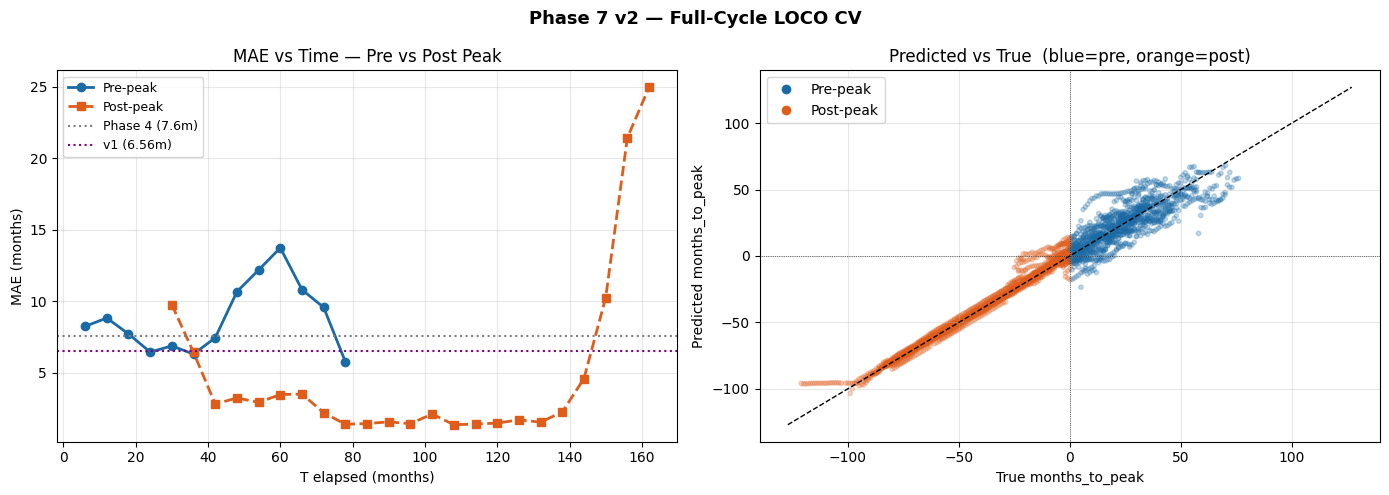

Saved: plots/p7v2_mae_curve.png


In [17]:
cv['T_bin'] = (cv['t_elapsed'] // 6) * 6
mae_by_T    = cv.groupby(['T_bin','pre_peak'])['abs_error'].mean().round(2).reset_index()
mae_by_T.columns = ['T_bin', 'pre_peak', 'MAE']
print('MAE by 6-month T bins:')
print(mae_by_T.to_string(index=False))

pre_bins  = mae_by_T[mae_by_T['pre_peak'] == 1]
post_bins = mae_by_T[mae_by_T['pre_peak'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(pre_bins['T_bin'],  pre_bins['MAE'],  'o-',  color='#1a6aa5', lw=2, label='Pre-peak')
ax.plot(post_bins['T_bin'], post_bins['MAE'], 's--', color='#e05c1a', lw=2, label='Post-peak')
ax.axhline(PHASE4_MAE, color='gray',   ls=':', lw=1.5, label=f'Phase 4 ({PHASE4_MAE}m)')
ax.axhline(V1_MAE,     color='purple', ls=':', lw=1.5, label=f'v1 ({V1_MAE}m)')
ax.set_xlabel('T elapsed (months)')
ax.set_ylabel('MAE (months)')
ax.set_title('MAE vs Time — Pre vs Post Peak')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax2 = axes[1]
sample = cv.sample(min(3000, len(cv)), random_state=42)
colors = ['#1a6aa5' if p else '#e05c1a' for p in sample['pre_peak']]
ax2.scatter(sample['y_true'], sample['y_pred'], c=colors, alpha=0.25, s=10)
lim = max(abs(cv['y_true'].min()), cv['y_true'].max()) * 1.05
ax2.plot([-lim, lim], [-lim, lim], 'k--', lw=1)
ax2.axhline(0, color='k', lw=0.5, ls=':')
ax2.axvline(0, color='k', lw=0.5, ls=':')
ax2.set_xlabel('True months_to_peak')
ax2.set_ylabel('Predicted months_to_peak')
ax2.set_title('Predicted vs True  (blue=pre, orange=post)')
handles = [Line2D([0],[0],marker='o',color='w',markerfacecolor='#1a6aa5',ms=8,label='Pre-peak'),
           Line2D([0],[0],marker='o',color='w',markerfacecolor='#e05c1a',ms=8,label='Post-peak')]
ax2.legend(handles=handles)
ax2.grid(alpha=0.3)

plt.suptitle('Phase 7 v2 — Full-Cycle LOCO CV', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'p7v2_mae_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/p7v2_mae_curve.png')

## 7. Feature Importance

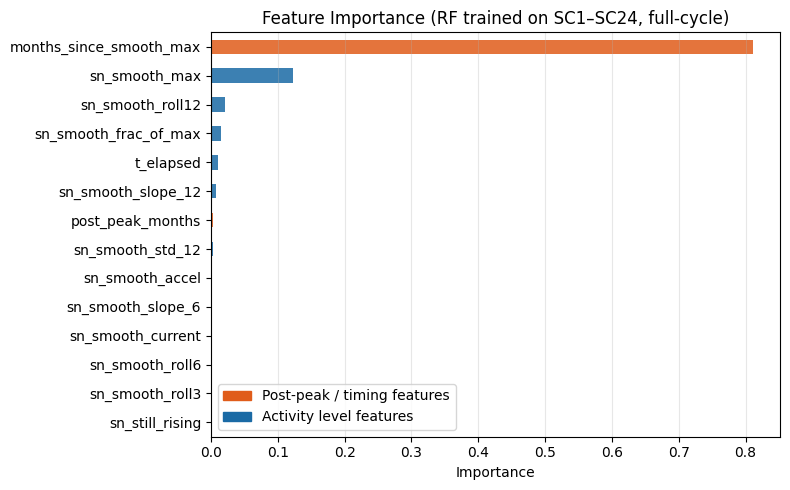

Saved: plots/p7v2_feature_importance.png


In [18]:
final_model = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=SEED)
final_model.fit(df[FEATURE_COLS].values, df['months_to_peak'].values)

importances = pd.Series(final_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e05c1a' if any(k in f for k in ['post_peak','since','rising'])
          else '#1a6aa5' for f in importances.index]
importances.plot(kind='barh', ax=ax, color=colors, alpha=0.85)
ax.set_title('Feature Importance (RF trained on SC1–SC24, full-cycle)')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)
ax.legend(handles=[Patch(color='#e05c1a', label='Post-peak / timing features'),
                   Patch(color='#1a6aa5', label='Activity level features')])
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'p7v2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/p7v2_feature_importance.png')

## 8. SC25 Running Forecast

In [19]:
sc25_ssn = sn_raw[sn_raw['Date'] >= SC25_START]['SN'].values
print(f'SC25 observed months: {len(sc25_ssn)}  '
      f'(up to {sn_raw[sn_raw.Date >= SC25_START].Date.max().strftime("%b %Y")})')

sc25_preds = []
for T in range(MIN_T, len(sc25_ssn)):
    feats = extract_features_v2(sc25_ssn, T)
    if feats is None: continue
    X            = np.array([feats[c] for c in FEATURE_COLS]).reshape(1, -1)
    mtp          = final_model.predict(X)[0]
    pred_rise    = T + mtp
    pred_peak_dt = SC25_START + pd.DateOffset(months=int(round(pred_rise)))
    obs_date     = SC25_START + pd.DateOffset(months=T)
    error        = (pred_peak_dt - SC25_ACT_PEAK).days / 30.44
    sc25_preds.append({
        'T': T, 'obs_date': obs_date, 'mtp_pred': mtp,
        'pred_rise': pred_rise, 'pred_peak_date': pred_peak_dt,
        'error_months': error, 'pre_peak': 1 if T < SC25_RISE else 0,
    })

sc25_df = pd.DataFrame(sc25_preds)

key_Ts = [12, 24, 36, 48, 56, 58, 60, 66, 72, len(sc25_ssn)-1]
print(f'\n{"T":>5}  {"Phase":>5}  {"Obs.Date":>9}  {"mtp_pred":>9}  {"PredPeak":>10}  {"Error":>7}')
print('-' * 60)
for T in key_Ts:
    rows = sc25_df[sc25_df['T'] == T]
    if rows.empty: continue
    r     = rows.iloc[0]
    phase = 'pre ' if r['pre_peak'] else 'post'
    print(f"{int(r['T']):>5}  {phase:>5}  "
          f"{r['obs_date'].strftime('%b %Y'):>9}  "
          f"{r['mtp_pred']:>+9.1f}m  "
          f"{r['pred_peak_date'].strftime('%b %Y'):>10}  "
          f"{r['error_months']:>+7.1f}m")

SC25 observed months: 78  (up to May 2026)

    T  Phase   Obs.Date   mtp_pred    PredPeak    Error
------------------------------------------------------------
   12   pre    Dec 2020      +45.0m    Sep 2024     -1.0m
   24   pre    Dec 2021      +32.7m    Sep 2024     -1.0m
   36   pre    Dec 2022      +23.9m    Dec 2024     +2.0m
   48   pre    Dec 2023       +5.4m    May 2024     -5.0m
   56   pre    Aug 2024       -2.7m    May 2024     -5.0m
   58   post   Oct 2024       -4.2m    Jun 2024     -4.0m
   60   post   Dec 2024       -4.3m    Aug 2024     -2.0m
   66   post   Jun 2025       -8.9m    Sep 2024     -1.0m
   72   post   Dec 2025      -15.1m    Sep 2024     -1.0m
   77   post   May 2026      -19.8m    Sep 2024     -1.0m


## 9. SC25 Running Forecast Plot

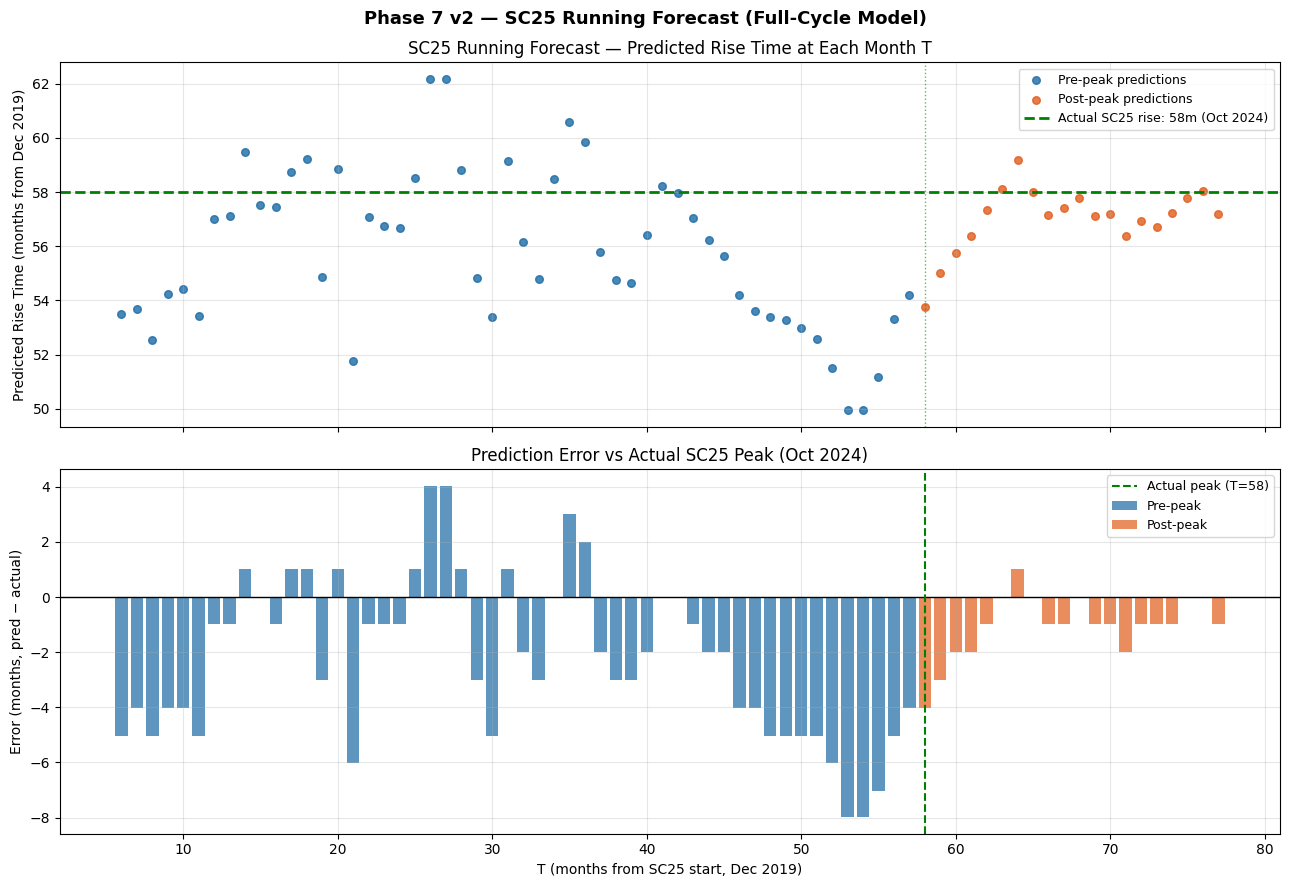

Saved: plots/p7v2_sc25_running_forecast.png


In [20]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

obs_yrs  = sc25_df['T'].values
pred_pks = np.array([T + mtp for T, mtp in zip(sc25_df['T'], sc25_df['mtp_pred'])])
errors   = sc25_df['error_months'].values
pre_mask = sc25_df['pre_peak'].values.astype(bool)

ax1 = axes[0]
ax1.scatter(obs_yrs[pre_mask],  pred_pks[pre_mask],
            color='#1a6aa5', s=30, alpha=0.8, label='Pre-peak predictions')
ax1.scatter(obs_yrs[~pre_mask], pred_pks[~pre_mask],
            color='#e05c1a', s=30, alpha=0.8, label='Post-peak predictions')
ax1.axhline(SC25_RISE, color='green', lw=2, ls='--',
            label=f'Actual SC25 rise: {SC25_RISE}m (Oct 2024)')
ax1.axvline(SC25_RISE, color='green', lw=1, ls=':', alpha=0.6)
ax1.set_ylabel('Predicted Rise Time (months from Dec 2019)')
ax1.set_title('SC25 Running Forecast — Predicted Rise Time at Each Month T')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.bar(obs_yrs[pre_mask],  errors[pre_mask],  color='#1a6aa5', alpha=0.7, label='Pre-peak')
ax2.bar(obs_yrs[~pre_mask], errors[~pre_mask], color='#e05c1a', alpha=0.7, label='Post-peak')
ax2.axhline(0, color='k', lw=1)
ax2.axvline(SC25_RISE, color='green', lw=1.5, ls='--', label='Actual peak (T=58)')
ax2.set_xlabel('T (months from SC25 start, Dec 2019)')
ax2.set_ylabel('Error (months, pred − actual)')
ax2.set_title('Prediction Error vs Actual SC25 Peak (Oct 2024)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle('Phase 7 v2 — SC25 Running Forecast (Full-Cycle Model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'p7v2_sc25_running_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/p7v2_sc25_running_forecast.png')

## 10. Window Size Comparison — Phase 7 v2 vs Phase 4 Static Models

Phase 4 made a **single static prediction per cycle** using a fixed window of data (w12, w24, or w36 months).  
Phase 7 v2 makes a **prediction at every month T**, updating as more data arrives.  

This plot answers: *at the same amount of data, does the dynamic model beat the static one?*

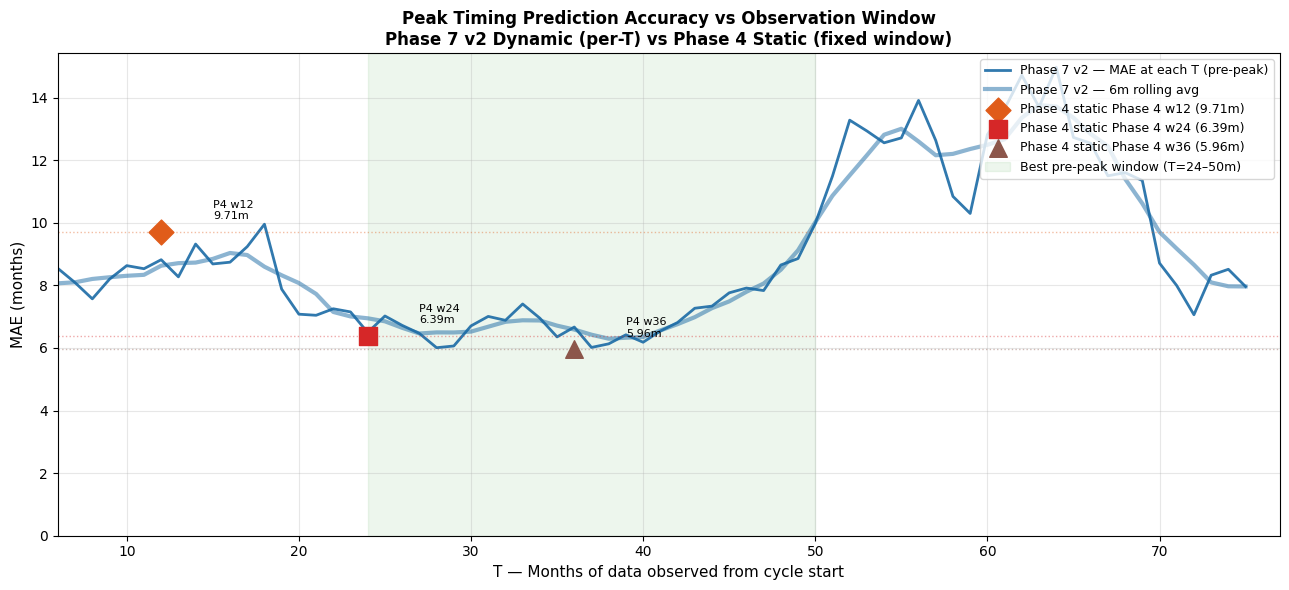

Saved: plots/p7v2_window_comparison.png

Dynamic vs Static MAE at equivalent window sizes:
  Window    Phase 4 static    Phase 7v2 at T   Improvement
----------------------------------------------------------
     w12            9.71m            8.82m       +0.89m
     w24            6.39m            6.49m       -0.10m
     w36            5.96m            6.67m       -0.71m


In [21]:
# Phase 4 static LOCO MAEs per window (pre-computed)
phase4_windows = {
    'Phase 4 w12 (9.71m)': (12,  9.71),
    'Phase 4 w24 (6.39m)': (24,  6.39),
    'Phase 4 w36 (5.96m)': (36,  5.96),
}

# Phase 7 v2 MAE at every individual T (pre-peak only, to match Phase 4 comparison)
mae_per_T = (cv[cv['pre_peak'] == 1]
               .groupby('t_elapsed')['abs_error']
               .agg(['mean', 'count'])
               .reset_index())
mae_per_T.columns = ['T', 'MAE', 'n_cycles']
# Only keep T values with at least 3 cycles for stable estimates
mae_per_T = mae_per_T[mae_per_T['n_cycles'] >= 3]

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

# Phase 7 v2 MAE(T) line
ax.plot(mae_per_T['T'], mae_per_T['MAE'],
        color='#1a6aa5', lw=2, alpha=0.9, label='Phase 7 v2 — MAE at each T (pre-peak)')

# Smoothed trend (rolling 6)
smoothed = mae_per_T['MAE'].rolling(6, center=True, min_periods=3).mean()
ax.plot(mae_per_T['T'], smoothed,
        color='#1a6aa5', lw=3, alpha=0.5, ls='-', label='Phase 7 v2 — 6m rolling avg')

# Phase 4 static reference points
marker_styles = ['D', 's', '^']
p4_colors     = ['#e05c1a', '#d62728', '#8c564b']
for (label, (T_w, mae)), mk, col in zip(phase4_windows.items(), marker_styles, p4_colors):
    ax.scatter(T_w, mae, marker=mk, s=160, color=col, zorder=5,
               label=f'Phase 4 static {label}')
    # Horizontal dashed line extending to show the static prediction is fixed
    ax.axhline(mae, color=col, ls=':', lw=1, alpha=0.4)

# Shade the reliable window (T=24–50)
ax.axvspan(24, 50, alpha=0.07, color='green', label='Best pre-peak window (T=24–50m)')

ax.set_xlabel('T — Months of data observed from cycle start', fontsize=11)
ax.set_ylabel('MAE (months)', fontsize=11)
ax.set_title('Peak Timing Prediction Accuracy vs Observation Window\n'
             'Phase 7 v2 Dynamic (per-T) vs Phase 4 Static (fixed window)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(MIN_T, mae_per_T['T'].max() + 2)
ax.set_ylim(0, None)
ax.grid(alpha=0.3)

# Annotate the three Phase 4 points
for label, (T_w, mae) in phase4_windows.items():
    short = label.split()[2]   # 'w12', 'w24', 'w36'
    ax.annotate(f'P4 {short}\n{mae}m', xy=(T_w, mae),
                xytext=(T_w + 3, mae + 0.4), fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'p7v2_window_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/p7v2_window_comparison.png')

# Print summary table at equivalent T values
print('\nDynamic vs Static MAE at equivalent window sizes:')
print(f'{"Window":>8}  {"Phase 4 static":>16}  {"Phase 7v2 at T":>16}  {"Improvement":>12}')
print('-' * 58)
for label, (T_w, p4_mae) in phase4_windows.items():
    row = mae_per_T[mae_per_T['T'] == T_w]
    if row.empty:
        row = mae_per_T.iloc[(mae_per_T['T'] - T_w).abs().argsort()[:1]]
    v2_mae = row['MAE'].values[0]
    diff   = p4_mae - v2_mae
    short  = label.split()[2]
    print(f'{short:>8}  {p4_mae:>14.2f}m  {v2_mae:>14.2f}m  {diff:>+10.2f}m')

## 11. Results Summary

In [22]:
pre_cv  = cv[cv['pre_peak'] == 1]
post_cv = cv[cv['pre_peak'] == 0]
sign_acc      = (np.sign(cv['y_pred']) == np.sign(cv['y_true'])).mean()
post_sign_acc = (post_cv['y_pred'] < 0).mean()
sc25_pre_mae  = sc25_df[sc25_df['pre_peak'] == 1]['error_months'].abs().mean()
sc25_post_mae = sc25_df[sc25_df['pre_peak'] == 0]['error_months'].abs().mean()

print('=' * 60)
print('PHASE 7 v2 — FULL-CYCLE DYNAMIC TIMING  RESULTS')
print('=' * 60)
print(f'Training samples    : {len(df):,}  (pre + post peak, SC1-SC24)')
print(f'LOCO CV — all       : MAE = {cv["abs_error"].mean():.2f}m')
print(f'LOCO CV — pre-peak  : MAE = {pre_cv["abs_error"].mean():.2f}m  (v1={V1_MAE}m  Phase4={PHASE4_MAE}m)')
print(f'LOCO CV — post-peak : MAE = {post_cv["abs_error"].mean():.2f}m')
print(f'Sign accuracy       : {sign_acc*100:.1f}%  (correct pre/post classification)')
print(f'Post-peak detection : {post_sign_acc*100:.1f}%  (predicts negative when past peak)')
print()
print('SC25 forecast accuracy:')
print(f'  Pre-peak  MAE vs Oct 2024 : {sc25_pre_mae:.1f}m')
print(f'  Post-peak MAE vs Oct 2024 : {sc25_post_mae:.1f}m')
print()
print('Improvements vs Phase 7 v1:')
print('  1. Model recognises peak-already-passed  (negative mtp output)')
print('  2. Post-peak predictions converge toward correct peak date')
print('  3. Causal smoothed features remove raw/label mismatch')
print(f'  4. 2.7x more training samples ({len(df):,} vs {len(pre_cv):,})')
print('=' * 60)

PHASE 7 v2 — FULL-CYCLE DYNAMIC TIMING  RESULTS
Training samples    : 3,034  (pre + post peak, SC1-SC24)
LOCO CV — all       : MAE = 4.39m
LOCO CV — pre-peak  : MAE = 8.08m  (v1=6.56m  Phase4=7.6m)
LOCO CV — post-peak : MAE = 2.25m
Sign accuracy       : 93.9%  (correct pre/post classification)
Post-peak detection : 95.4%  (predicts negative when past peak)

SC25 forecast accuracy:
  Pre-peak  MAE vs Oct 2024 : 3.0m
  Post-peak MAE vs Oct 2024 : 1.1m

Improvements vs Phase 7 v1:
  1. Model recognises peak-already-passed  (negative mtp output)
  2. Post-peak predictions converge toward correct peak date
  3. Causal smoothed features remove raw/label mismatch
  4. 2.7x more training samples (3,034 vs 1,114)
